## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [2]:
df = pd.read_csv('Loan_default.csv',index_col=0)
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
LoanID,,,,,,,,,,,,,,,,,
I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0


## Data Understanding

In [3]:
df.shape

(255347, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255347 entries, I38PQUQS96 to ZTH91CGL0B
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes:

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
df.describe(include=object)

,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255347,255347,255347,255347,255347,255347,255347
unique,4,4,3,2,2,5,2
top,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,64366,64161,85302,127677,127742,51298,127701


## Data Cleaning

In [7]:
df.isna().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

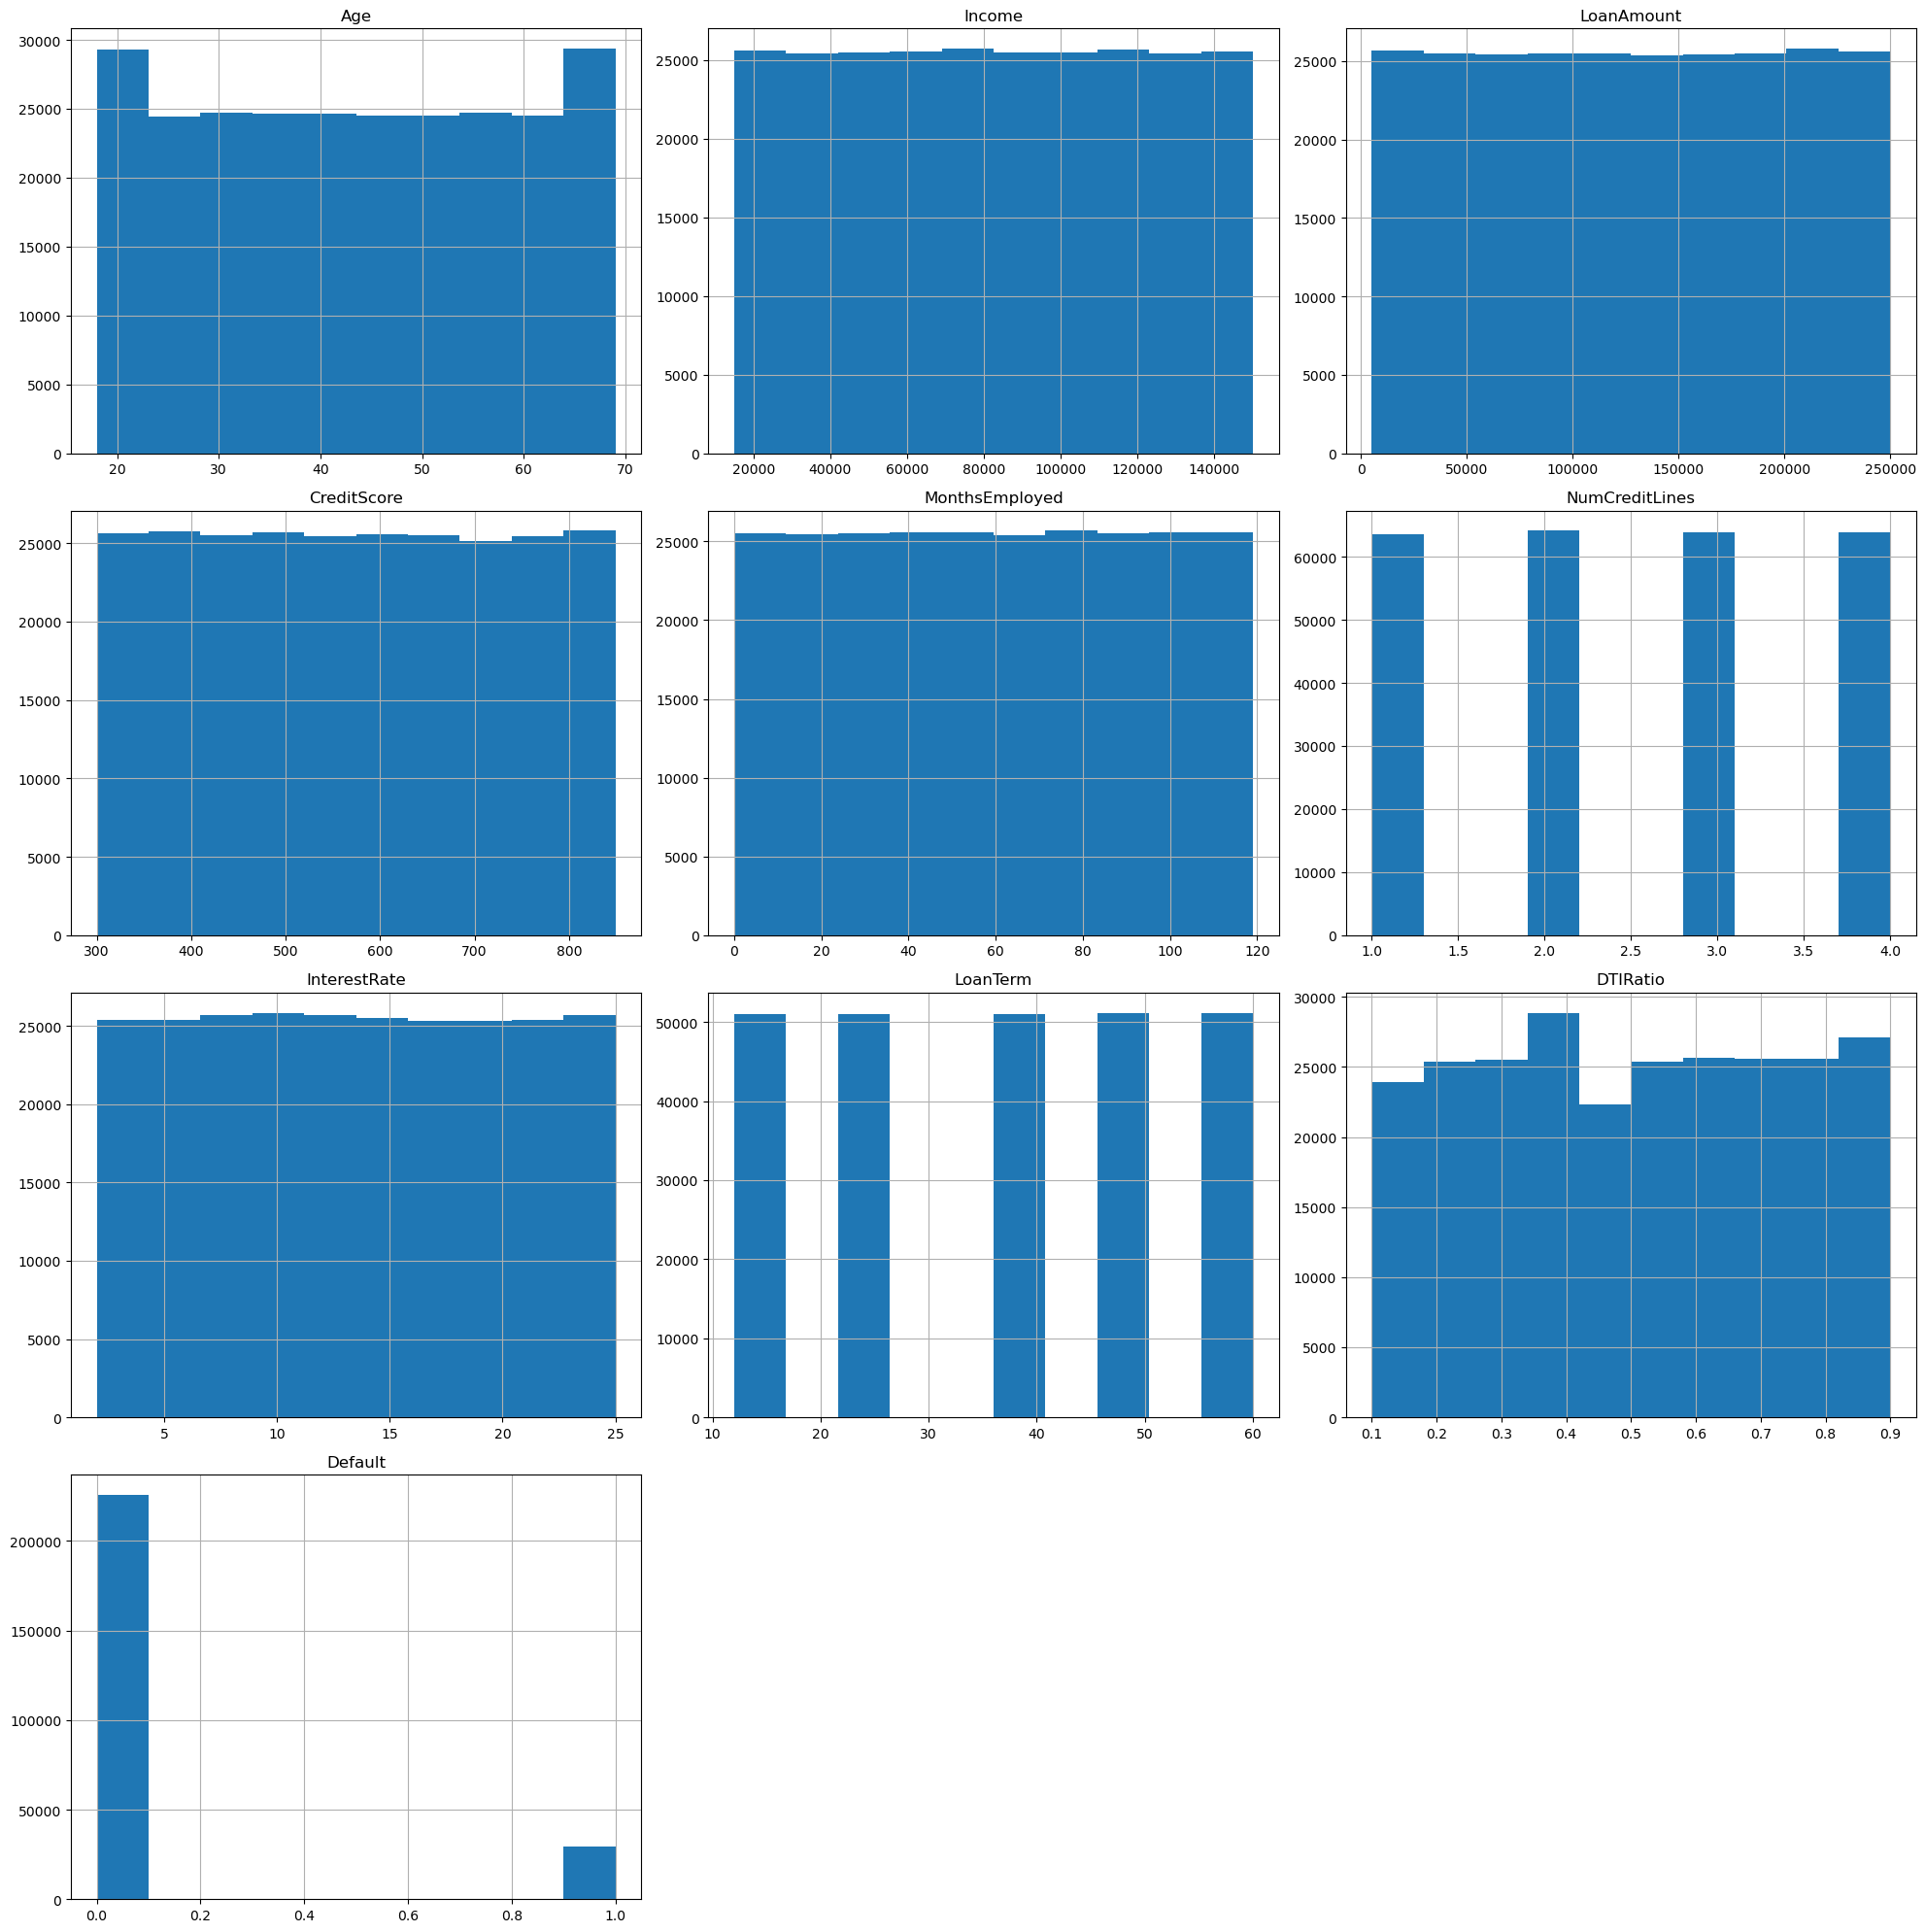

In [9]:
fig, axes = plt.subplots(figsize=(20, 20))
df.hist(ax=axes)
plt.tight_layout()
plt.show()

<Axes: xlabel='Default', ylabel='count'>

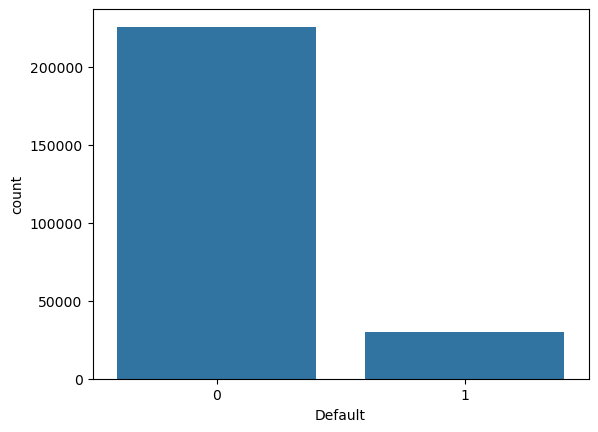

In [10]:
sns.countplot(x='Default', data=df)

<Axes: >

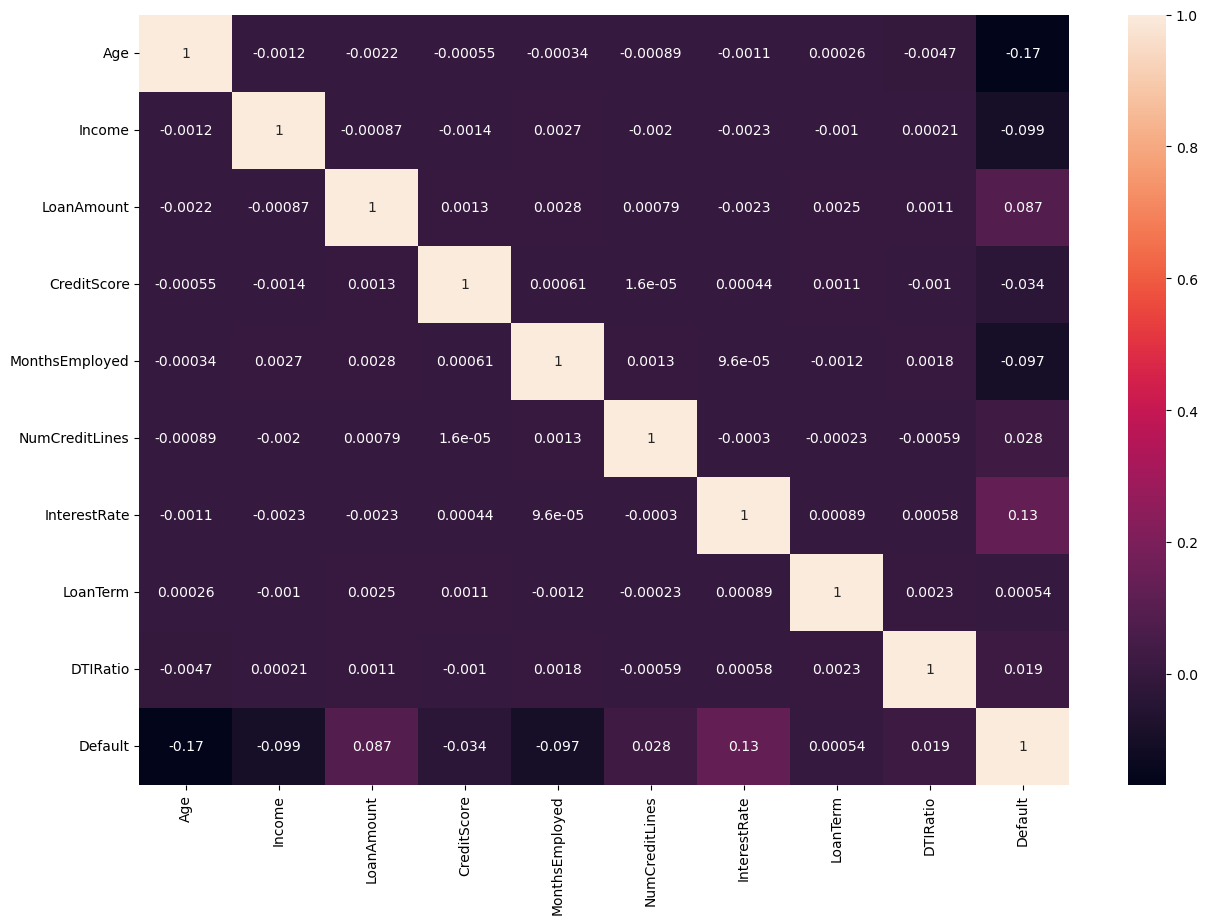

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [12]:
corr = df.corr(numeric_only=True)

corr['Default'].sort_values(ascending=False)

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

## Feature Engineering

In [13]:
df['loan_income_ratio'] = df['LoanAmount']/df['Income']

## Encoding 

In [14]:
for i in df.select_dtypes(include=object) :
    print(i,df[i].unique())

Education ["Bachelor's" "Master's" 'High School' 'PhD']
EmploymentType ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
MaritalStatus ['Divorced' 'Married' 'Single']
HasMortgage ['Yes' 'No']
HasDependents ['Yes' 'No']
LoanPurpose ['Other' 'Auto' 'Business' 'Home' 'Education']
HasCoSigner ['Yes' 'No']


In [15]:
df['Education'] = df['Education'].map({
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'PhD': 3
})

In [16]:

df['EmploymentType'] = df['EmploymentType'].map({
    'Unemployed': 0,
    'Part-time': 1,
    'Self-employed': 2,
    'Full-time': 3
})


In [17]:

df['MaritalStatus'] = df['MaritalStatus'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})


In [18]:

df['HasMortgage'] = df['HasMortgage'].map({'No': 0, 'Yes': 1})
df['HasDependents'] = df['HasDependents'].map({'No': 0, 'Yes': 1})
df['HasCoSigner'] = df['HasCoSigner'].map({'No': 0, 'Yes': 1})


In [19]:

df['LoanPurpose'] = df['LoanPurpose'].map({
    'Other': 0,
    'Education': 1,
    'Auto': 2,
    'Home': 3,
    'Business': 4
})

## Feature Selection

In [20]:
X = df.drop('Default', axis=1)
y = df['Default']

In [21]:
# Train test split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Model Building

In [22]:
model = LGBMClassifier(random_state=42)

In [23]:
model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 23722, number of negative: 180555
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1562
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116127 -> initscore=-2.029633
[LightGBM] [Info] Start training from score -2.029633


LGBMClassifier(random_state=42)

## Make Predictions

In [24]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## Evaluate the Model

In [25]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))

Accuracy : 0.8866849422361465
Precision: 0.6139240506329114
Recall   : 0.0654189849940988
F1 Score : 0.11823861039158921
ROC AUC  : 0.7572121115805989


In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[44895   244]
 [ 5543   388]]


In [27]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



## Hyperparameters tuning

In [28]:
param_dist = {
    'max_depth': [4, 6, 8, 10],
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 500, 1000],
    'min_child_samples': [20, 50, 100]
}


In [29]:

rscv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rscv.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 23722, number of negative: 180555
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1562
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116127 -> initscore=-2.029633
[LightGBM] [Info] Start training from score -2.029633
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

RandomizedSearchCV(cv=3, estimator=LGBMClassifier(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'min_child_samples': [20, 50, 100],
                                        'n_estimators': [200, 500, 1000],
                                        'num_leaves': [15, 31, 63, 127]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [30]:
print("Best Params:", rscv.best_params_)
print("Best CV Score:", rscv.best_score_)

Best Params: {'num_leaves': 31, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': 4, 'learning_rate': 0.01}
Best CV Score: 0.7527906832885956


In [31]:
best_model = rscv.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.886724104170746
Precision: 0.6341911764705882
Recall   : 0.058168942842690946
F1 Score : 0.10656370656370656
ROC AUC  : 0.7593242632625116


In [33]:
for t in [0.10, 0.15, 0.20, 0.25, 0.30]:
    y_pred = (y_prob >= t).astype(int)
    print(
        f"Threshold={t}",
        f"F1={f1_score(y_test, y_pred):.4f}"
    )

Threshold=0.1 F1=0.3266
Threshold=0.15 F1=0.3660
Threshold=0.2 F1=0.3716
Threshold=0.25 F1=0.3470
Threshold=0.3 F1=0.3068


In [34]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred_final = (y_prob >= 0.2).astype(int)

## Feature Importance 

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,InterestRate,2220
4,MonthsEmployed,2073
16,loan_income_ratio,1988
0,Age,1676
3,CreditScore,1315
1,Income,908
8,DTIRatio,860
2,LoanAmount,675
10,EmploymentType,627
9,Education,529


In [36]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

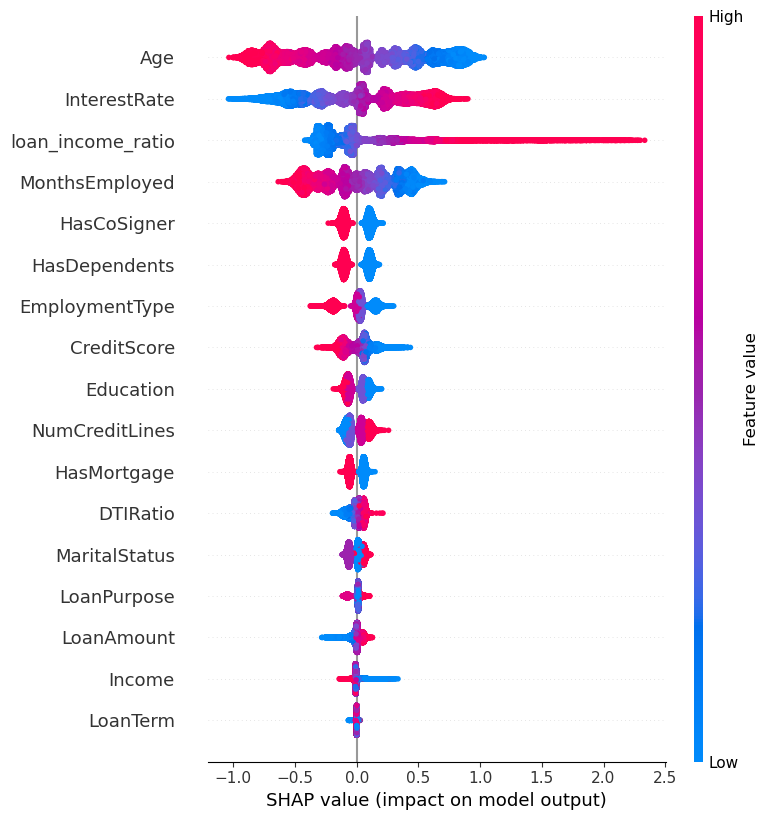

In [37]:
shap.summary_plot(
    shap_values,
    X_test
)

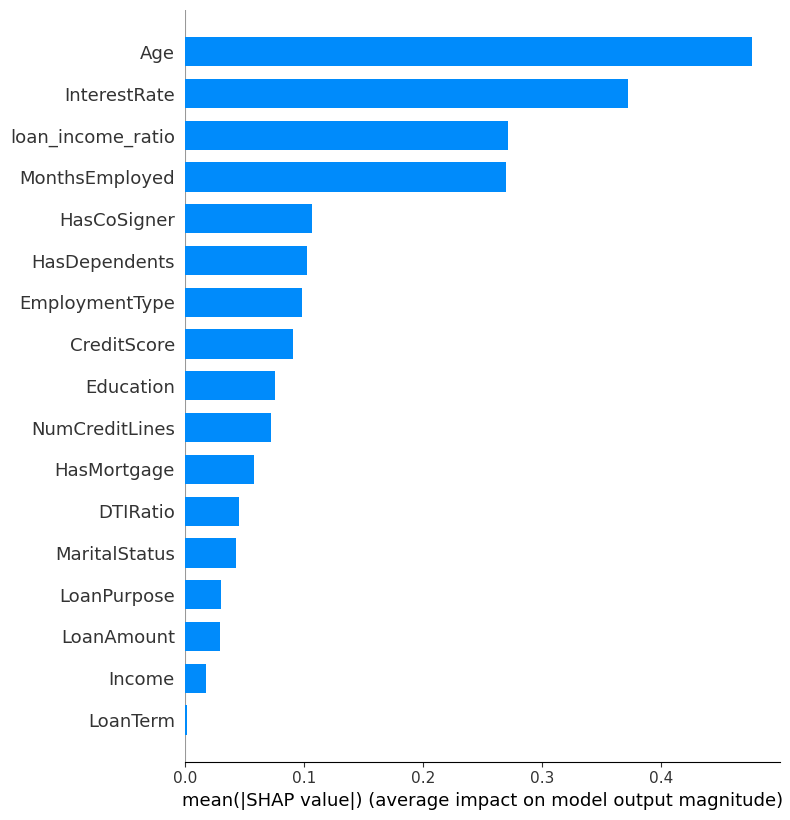

In [38]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

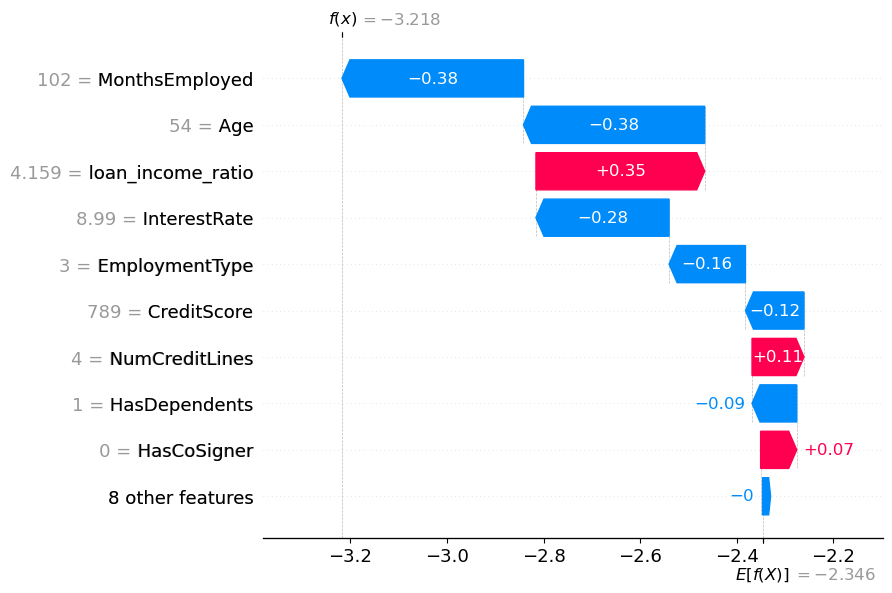

In [39]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## Save the Final Model

In [40]:
import joblib

joblib.dump(best_model, 'loan_default_lightgbm.pkl')

print("Model saved successfully!")

Model saved successfully!


## Load Model 

In [41]:
model = joblib.load('loan_default_lightgbm.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [42]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.20).astype(int)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(51070,))

## Conclusion

This project focused on predicting loan defaults using demographic, employment, financial, and credit-related information. The dataset contained both numerical and categorical features, making LightGBM an effective choice due to its efficient gradient boosting framework, fast training speed, and ability to handle categorical features with minimal preprocessing.

The data was cleaned, explored, and prepared through exploratory data analysis (EDA) and feature engineering. A LightGBM Classifier was trained and subsequently optimized using RandomizedSearchCV to improve model performance. The tuned model achieved a ROC-AUC score of approximately 0.759, demonstrating a strong ability to distinguish between borrowers who are likely to default and those who are not.

Given the class imbalance present in the dataset, model evaluation focused on Precision, Recall, F1 Score, and ROC-AUC rather than accuracy alone. Hyperparameter tuning resulted in a modest improvement in ROC-AUC, indicating better ranking and discrimination performance. Further performance gains can be achieved through threshold optimization, allowing the model to better balance precision and recall based on business requirements.

Feature importance analysis and SHAP-based explainability were used to identify the primary drivers of loan default risk. Key factors included Interest Rate, Credit Score, Debt-to-Income Ratio (DTI), Income, Loan Amount, Employment History, and other borrower-related financial indicators. These insights provide transparency into model decisions and support more informed risk assessment.

Overall, this project demonstrates a complete machine learning workflow including data preprocessing, exploratory data analysis, feature engineering, LightGBM model development, hyperparameter tuning, threshold optimization, performance evaluation, and explainable AI techniques for credit risk assessment.


## Try with XGBoost

In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8862541609555512
Precision: 0.5826558265582655
Recall   : 0.07250042151407857
F1 Score : 0.12895486579697105
ROC AUC  : 0.7549566643485307


In [44]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best Params:", search.best_params_)
print("Best CV Score:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.7, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV Score: 0.7539873311530204


In [47]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [48]:

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8867045232034463
Precision: 0.6243567753001715
Recall   : 0.06137244983982465
F1 Score : 0.1117592876880565
ROC AUC  : 0.7600449543798298
